In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**<span style="font-size: 20px;">№1. Генерация данных</span>**

In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

**<span style="font-size: 16px;">Визуализация данных</span>**

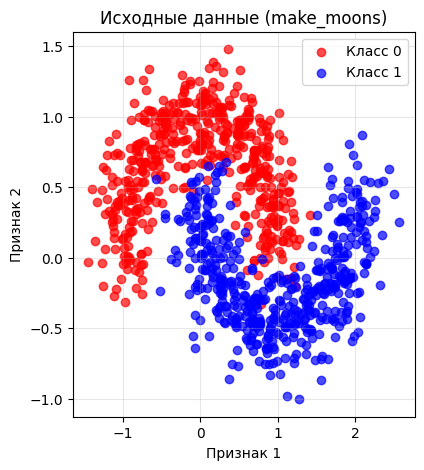

In [3]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', alpha=0.7, label='Класс 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', alpha=0.7, label='Класс 1')
plt.title('Исходные данные (make_moons)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

**<span style="font-size: 20px;">№2. Создание MLP модели</span>**

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(2, 4)  # вход: 2 нейрона, скрытый слой: 4 нейрона
        self.output = nn.Linear(4, 1)  # выход: 1 нейрон
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.hidden(x))  # скрытый слой с ReLU
        x = self.sigmoid(self.output(x))  # выходной слой с sigmoid
        return x

**<span style="font-size: 20px;">№3. Разделение данных на обучающую и тестовую выборки</span>**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**<span style="font-size: 16px;">Нормализация данных</span>**

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (800, 2)
Размер тестовой выборки: (200, 2)


**<span style="font-size: 16px;">Создание модели, функции потерь и оптимизатора</span>**

In [ ]:
model = MLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

**<span style="font-size: 20px;">№4. Обучение модели</span>**

In [9]:
epochs = 1000
train_losses = []

for epoch in range(epochs):
    # Прямой проход
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Обратный проход и оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f'Эпоха [{epoch}/{epochs}], Потеря: {loss.item():.4f}')

Эпоха [0/1000], Потеря: 0.7011
Эпоха [100/1000], Потеря: 0.3236
Эпоха [200/1000], Потеря: 0.2652
Эпоха [300/1000], Потеря: 0.1839
Эпоха [400/1000], Потеря: 0.1347
Эпоха [500/1000], Потеря: 0.1133
Эпоха [600/1000], Потеря: 0.1042
Эпоха [700/1000], Потеря: 0.1000
Эпоха [800/1000], Потеря: 0.0977
Эпоха [900/1000], Потеря: 0.0964


**<span style="font-size: 16px;">График потерь</span>**

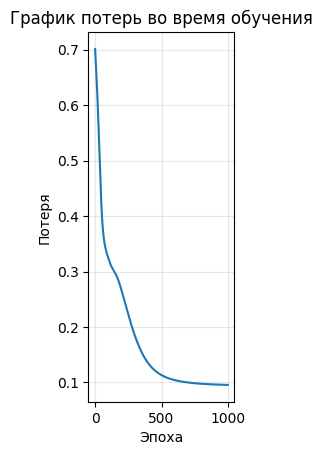

In [ ]:
plt.subplot(1, 3, 2)
plt.plot(train_losses)
plt.title('График потерь во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.grid(True, alpha=0.3)

**<span style="font-size: 20px;">№5. Оценка точности на тестовой выборке</span>**

In [11]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_preds = (test_outputs > 0.5).float()
    accuracy = (test_preds == y_test_tensor).float().mean()
    
print(f'Точность на тестовой выборке: {accuracy.item()*100:.2f}%')

Точность на тестовой выборке: 98.50%


**<span style="font-size: 16px;">Визуализация результатов классификации</span>**

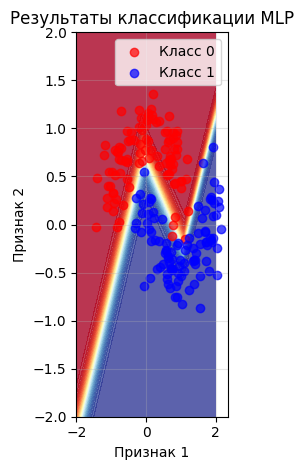

In [ ]:
plt.subplot(1, 3, 3)
xx, yy = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(scaler.transform(grid))

with torch.no_grad():
    Z = model(grid_tensor).numpy()
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdYlBu')
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], 
           color='red', alpha=0.7, label='Класс 0')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], 
           color='blue', alpha=0.7, label='Класс 1')
plt.title('Результаты классификации MLP')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()